# GeoBrain Karst Cave Detection via Implicit Geological Modeling

Recover cave geometry from post-stack seismic data by inverting
through the full forward chain:

Cave boundary (z-coords)  →  Implicit Model (lithology)
→  Rock properties (Vp, ρ)
→  Acoustic impedance & reflectivity
→  Wavelet convolution → Synthetic seismic

A karst cave (low-impedance anomaly) embedded in uniform limestone.
The cave boundary is parameterized by top and bottom z-coordinates
at fixed x-positions.  Two optimizers compared: Adam vs Adam+L-BFGS (hybrid).

---

This example demonstrates **karst cave detection** from post-stack seismic
data by inverting through a differentiable forward chain:

```
Cave boundary (z-coords) → Implicit model (lithology)
                         → Rock properties (Vp, ρ)
                         → Acoustic impedance & reflectivity
                         → Wavelet convolution → Synthetic seismic
```

Two optimisation strategies are compared: **Adam** and **Adam + L-BFGS**
(hybrid).

In [1]:
import sys
import os
sys.path.insert(0, '../..')

import torch
import matplotlib.pyplot as plt
import numpy as np

from geobrain.geomodel.implicit import (
    ImplicitModel,
    ImplicitModelConfig,
    SeriesDefinition,
    SurfacePointData,
    OrientationData,
)
from geobrain.physics.wave import RickerWavelet, create_conv_matrix, normal_incidence_rc
from geobrain.optim import Inverter, bound_constraint
from geobrain.vis import plot_field, plot_comparison

DEVICE = torch.device("cpu")
SEED = 2025
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

## Modelling Parameters

| Parameter | Value | Description |
|-----------|-------|-------------|
| Grid | 80 × 160 | Physical size 400 m × 300 m |
| Cave fill | Vp = 2200 m/s, ρ = 1800 kg/m³ | Low-impedance anomaly |
| Limestone host | Vp = 5000 m/s, ρ = 2650 kg/m³ | Background |
| Ricker wavelet | 50 Hz, dt = 2 ms | Seismic source signature |
| Temperature | 50 | Softmax sharpness in the implicit model |

In [3]:
NX, NZ = 80, 160
PHYS_X, PHYS_Z = 400.0, 300.0
DX = PHYS_X / (NX - 1)          # ~5 m
DZ = PHYS_Z / (NZ - 1)          # ~1.9 m

TEMPERATURE = 50.0

# Rock properties (2 units: cave fill vs limestone host)
#                    Cave fill    Limestone
VP_UNIT  = torch.tensor([2200., 5000.], dtype=torch.float64, device=DEVICE)
RHO_UNIT = torch.tensor([1800., 2650.], dtype=torch.float64, device=DEVICE)

# Seismic wavelet
FREQ = 50.0    # Hz
DT = 0.002     # s

## Cave Parameterization

The cave shape is controlled by **12 free parameters**: top and bottom
z-coordinates at 6 equally spaced x-positions.  Orientation data define the
"inside vs. outside" direction, enabling the implicit model to form a closed
body.

In [4]:
# 6 x-positions along the cave; at each: a top z and bottom z control point
N_X = 6
SP_X_POS = torch.tensor([0.34, 0.40, 0.46, 0.54, 0.60, 0.66],
                          dtype=torch.float64, device=DEVICE)
SP_X = SP_X_POS.repeat(2)                                        # (12,)
SP_IDS = torch.zeros(2 * N_X, dtype=torch.long, device=DEVICE)   # all one surface

# Orientation data: inner ring (inside cave) + outer ring (background)
# All gradients point radially outward from cave center (0.50, 0.50)
_r_in, _r_out = 0.04, 0.40
ORI_COORDS = torch.tensor([
    [0.50,         0.50 - _r_in],  [0.50,         0.50 + _r_in],
    [0.50 - _r_in, 0.50        ],  [0.50 + _r_in, 0.50        ],
    [0.50,         0.50 - _r_out], [0.50,         0.50 + _r_out],
    [0.50 - _r_out, 0.50       ],  [0.50 + _r_out, 0.50       ],
], dtype=torch.float64, device=DEVICE)
ORI_GRADS = torch.tensor([
    [0., -1.], [0., 1.], [-1., 0.], [1., 0.],
    [0., -1.], [0., 1.], [-1., 0.], [1., 0.],
], dtype=torch.float64, device=DEVICE)

CONFIG = ImplicitModelConfig(
    extent=(0.0, 1.0, 0.0, 1.0), resolution=(NX, NZ),
    device=str(DEVICE), dtype="float64",
    drift_degree=0,
)

## Seismic Wavelet

A Ricker wavelet (50 Hz) is generated and converted into a convolution
matrix `CONV_W` for efficient matrix–vector multiplication of the
reflectivity series.

In [5]:
ricker = RickerWavelet()
wavelet, _ = ricker(f0=FREQ, dt=DT, device=str(DEVICE))
wavelet = wavelet.to(dtype=torch.float64)

N_REFL = NZ - 1
CONV_W = create_conv_matrix(wavelet, N_REFL, mode='same').T.to(
    dtype=torch.float64, device=DEVICE,
)

## Forward Model

`forward_fn(sp_z)` implements the complete differentiable chain:

1. Assemble surface points from the z-coordinate vector
2. Build the implicit model → soft lithology probabilities
3. Mix rock properties (Vp, ρ) according to the soft weights
4. Compute normal-incidence reflection coefficients
5. Convolve with the Ricker wavelet → synthetic seismogram

In [6]:
def forward_fn(sp_z):
    """Cave boundary z-coords → synthetic seismic section.

    Args:
        sp_z: (2*N_X,) — first N_X are top z, last N_X are bottom z.
    """
    coords = torch.stack([SP_X, sp_z], dim=-1)
    sp = SurfacePointData(coords=coords, surface_id=SP_IDS)
    ori = OrientationData(coords=ORI_COORDS, gradients=ORI_GRADS)
    model = ImplicitModel(CONFIG, series=[SeriesDefinition("cave", sp, ori)])
    block = model(soft=True, temperature=TEMPERATURE)['block'].reshape(NX, NZ)

    w_lime = torch.sigmoid(TEMPERATURE * (block - 0.5))
    w_cave = 1.0 - w_lime

    vp  = w_cave * VP_UNIT[0] + w_lime * VP_UNIT[1]
    rho = w_cave * RHO_UNIT[0] + w_lime * RHO_UNIT[1]

    rc = normal_incidence_rc(
        vp[:, :-1], rho[:, :-1],
        vp[:, 1:],  rho[:, 1:],
    )
    return torch.einsum("ij,kj->ik", rc, CONV_W)


def build_impedance(sp_z):
    """Build acoustic impedance field for visualization."""
    coords = torch.stack([SP_X, sp_z], dim=-1)
    sp = SurfacePointData(coords=coords, surface_id=SP_IDS)
    ori = OrientationData(coords=ORI_COORDS, gradients=ORI_GRADS)
    model = ImplicitModel(CONFIG, series=[SeriesDefinition("cave", sp, ori)])
    block = model(soft=True, temperature=TEMPERATURE)['block'].reshape(NX, NZ)
    w_lime = torch.sigmoid(TEMPERATURE * (block - 0.5))
    w_cave = 1.0 - w_lime
    return w_cave * (VP_UNIT[0] * RHO_UNIT[0]) + w_lime * (VP_UNIT[1] * RHO_UNIT[1])


def to_image(data_2d):
    if isinstance(data_2d, torch.Tensor):
        data_2d = data_2d.detach().cpu().numpy()
    return data_2d.T

## True and Initial Models

- **True model**: an asymmetric cave, wider towards the centre-right
- **Initial model**: a flat-top, flat-bottom rectangle (mean of the true
  top/bottom z-values)

The initial model is the starting point for optimisation.

In [7]:
print("Generating true model...")

# True cave: asymmetric, wider in the center-right
Z_TOP_TRUE = torch.tensor([0.44, 0.40, 0.36, 0.35, 0.39, 0.43],
                            dtype=torch.float64, device=DEVICE)
Z_BOT_TRUE = torch.tensor([0.56, 0.60, 0.64, 0.65, 0.61, 0.57],
                            dtype=torch.float64, device=DEVICE)
SP_Z_TRUE = torch.cat([Z_TOP_TRUE, Z_BOT_TRUE])

with torch.no_grad():
    seis_obs = forward_fn(SP_Z_TRUE)

print(f"  Top z (true):    {Z_TOP_TRUE.tolist()}")
print(f"  Bottom z (true): {Z_BOT_TRUE.tolist()}")
print(f"  Seismic shape:   {seis_obs.shape}")
print(f"  Amplitude range: [{seis_obs.min():.4f}, {seis_obs.max():.4f}]")

print("Generating initial model...")

# Flat top/bottom at mean depths → rectangular cave
Z_TOP_INIT = Z_TOP_TRUE.mean().expand(N_X)
Z_BOT_INIT = Z_BOT_TRUE.mean().expand(N_X)
SP_Z_INIT = torch.cat([Z_TOP_INIT, Z_BOT_INIT]).to(device=DEVICE)

with torch.no_grad():
    seis_init = forward_fn(SP_Z_INIT)

print(f"  Top z (init):    {Z_TOP_INIT.tolist()}")
print(f"  Bottom z (init): {Z_BOT_INIT.tolist()}")

Generating true model...
  Top z (true):    [0.44, 0.4, 0.36, 0.35, 0.39, 0.43]
  Bottom z (true): [0.56, 0.6, 0.64, 0.65, 0.61, 0.57]
  Seismic shape:   torch.Size([80, 159])
  Amplitude range: [-0.1807, 0.1807]
Generating initial model...
  Top z (init):    [0.395, 0.395, 0.395, 0.395, 0.395, 0.395]
  Bottom z (init): [0.605, 0.605, 0.605, 0.605, 0.605, 0.605]


## Method 1 — Adam Optimiser

The `Inverter` performs gradient-based optimisation with bound constraints
$z \in [0.10, 0.90]$.  Adam is a robust first-order method that converges
quickly in early iterations.

- 500 iterations, learning rate 1 × 10⁻²
- MSE loss between observed and predicted seismic

In [8]:
print("\nRunning Cave Inversion (Adam)...")

inverter_adam = Inverter.create(
    initial_model=SP_Z_INIT.clone(),
    forward_fn=forward_fn,
    constraints=bound_constraint(0.10, 0.90),
)

result_adam = inverter_adam.run(
    observed_data=seis_obs,
    max_epochs=500,
    lr=1e-2,
    loss_fn='mse',
    verbose=True,
    print_every=100,
)

print(f"\n{result_adam.summary()}")
sp_z_adam = result_adam.best_model
print(f"Max z error: {(sp_z_adam - SP_Z_TRUE).abs().max():.6f}")


Running Cave Inversion (Adam)...

Inversion Result
Final loss: 1.010830e-05
Best loss: 1.010830e-05 (epoch 499)
Improvement: 99.9%
Epochs: 500
Time: 2.90s
Converged: False
Max z error: 0.049392


## Method 2 — Hybrid Adam + L-BFGS

A two-stage strategy: **Adam** first navigates the loss landscape broadly,
then **L-BFGS** (a quasi-Newton method exploiting curvature information)
refines the solution.  This often achieves lower final misfit than Adam
alone.

In [9]:
print("\nRunning Cave Inversion (Adam + L-BFGS)...")

inverter_lbfgs = Inverter.create(
    initial_model=SP_Z_INIT.clone(),
    forward_fn=forward_fn,
    constraints=bound_constraint(0.10, 0.90),
)

result_lbfgs = inverter_lbfgs.run(
    observed_data=seis_obs,
    max_epochs=500,
    optimizer='adam+lbfgs',
    lr=1e-2,
    loss_fn='mse',
    verbose=True,
    print_every=100,
)

print(f"\n{result_lbfgs.summary()}")
sp_z_lbfgs = result_lbfgs.best_model
print(f"Max z error: {(sp_z_lbfgs - SP_Z_TRUE).abs().max():.6f}")


Running Cave Inversion (Adam + L-BFGS)...

Inversion Result
Final loss: 6.295375e-09
Best loss: 6.295375e-09 (epoch 368)
Improvement: 100.0%
Epochs: 369
Time: 2.36s
Converged: False
Max z error: 0.023507


## Results Visualisation

Five figure panels compare the inversion outcomes:

1. **Acoustic impedance**: True vs. Initial vs. Adam vs. Adam+L-BFGS
2. **Seismic sections**: Observed vs. predicted data
3. **Residual maps**: Data misfit (NRMSE) for each method
4. **Convergence curves**: Loss vs. epoch
5. **Cave boundary recovery**: Inverted outlines overlaid on impedance

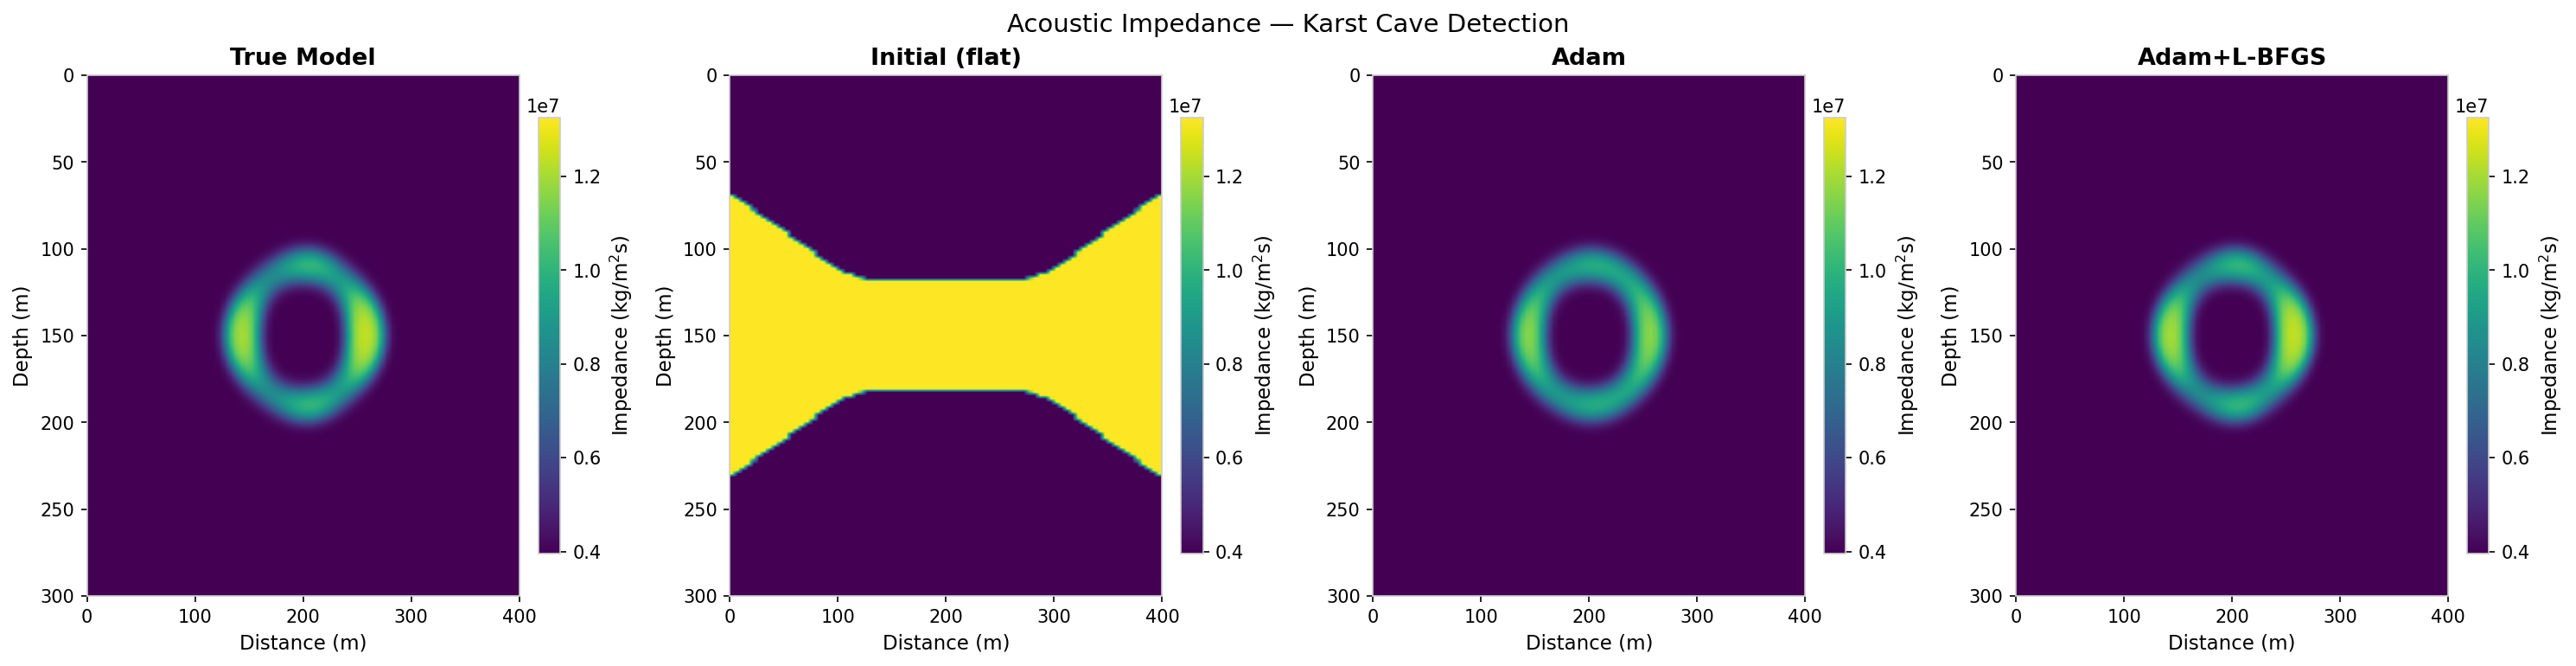

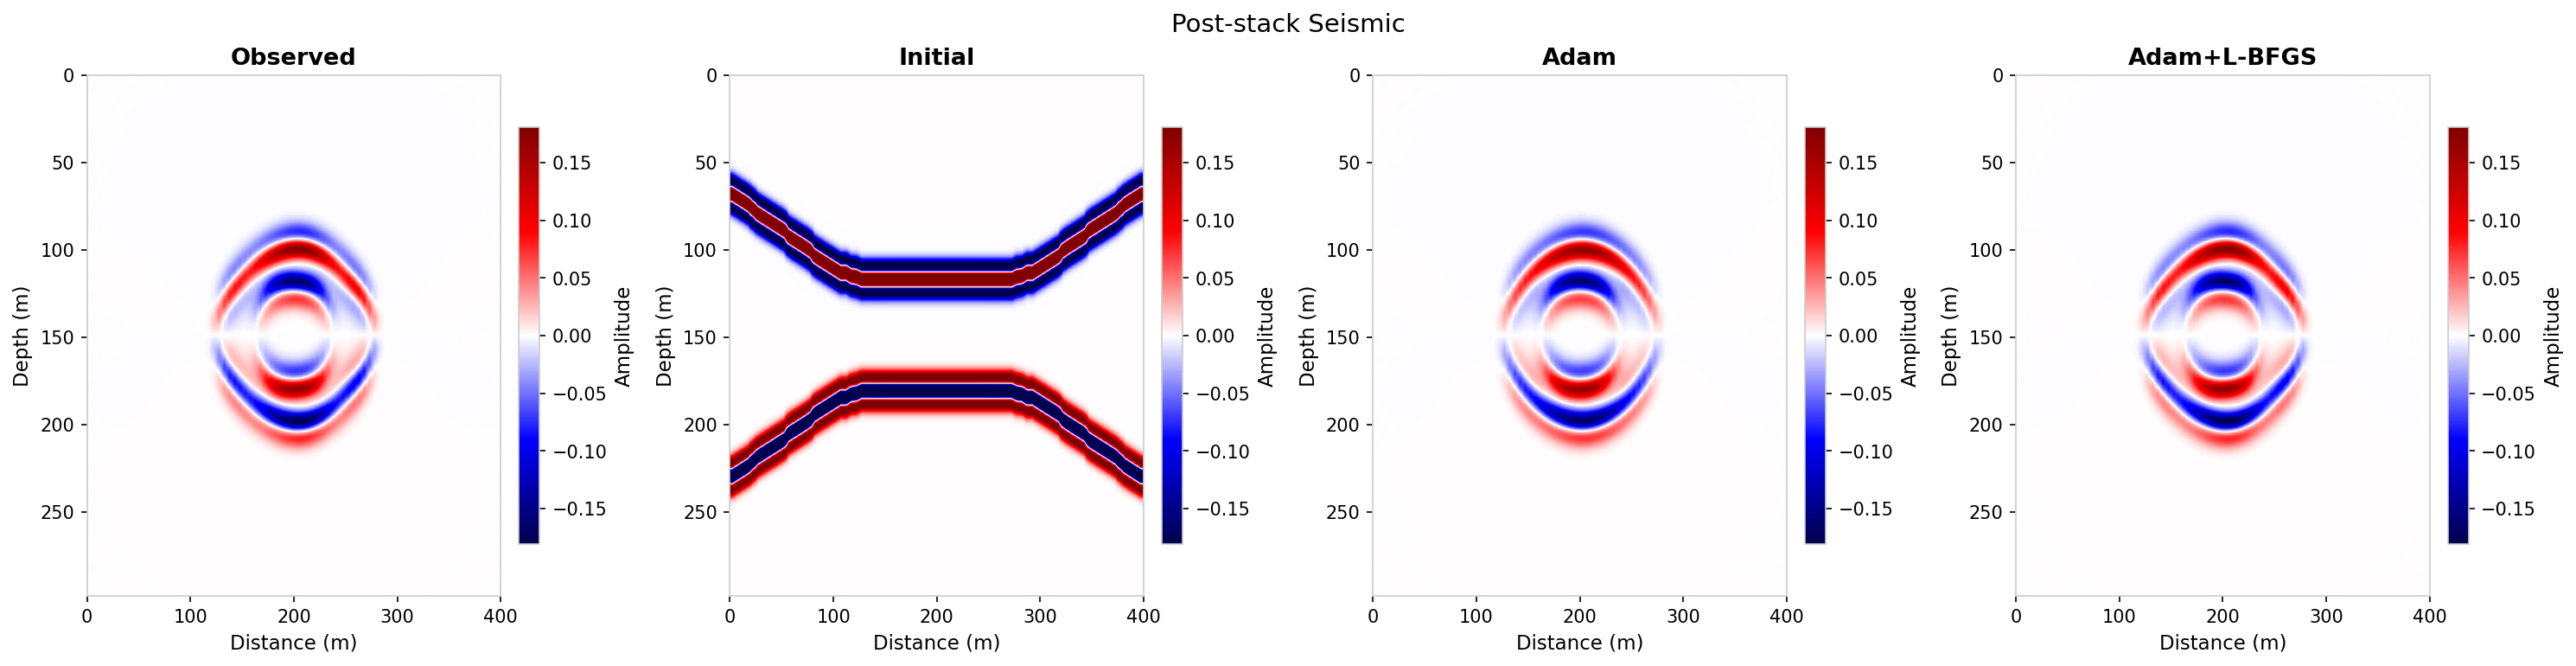

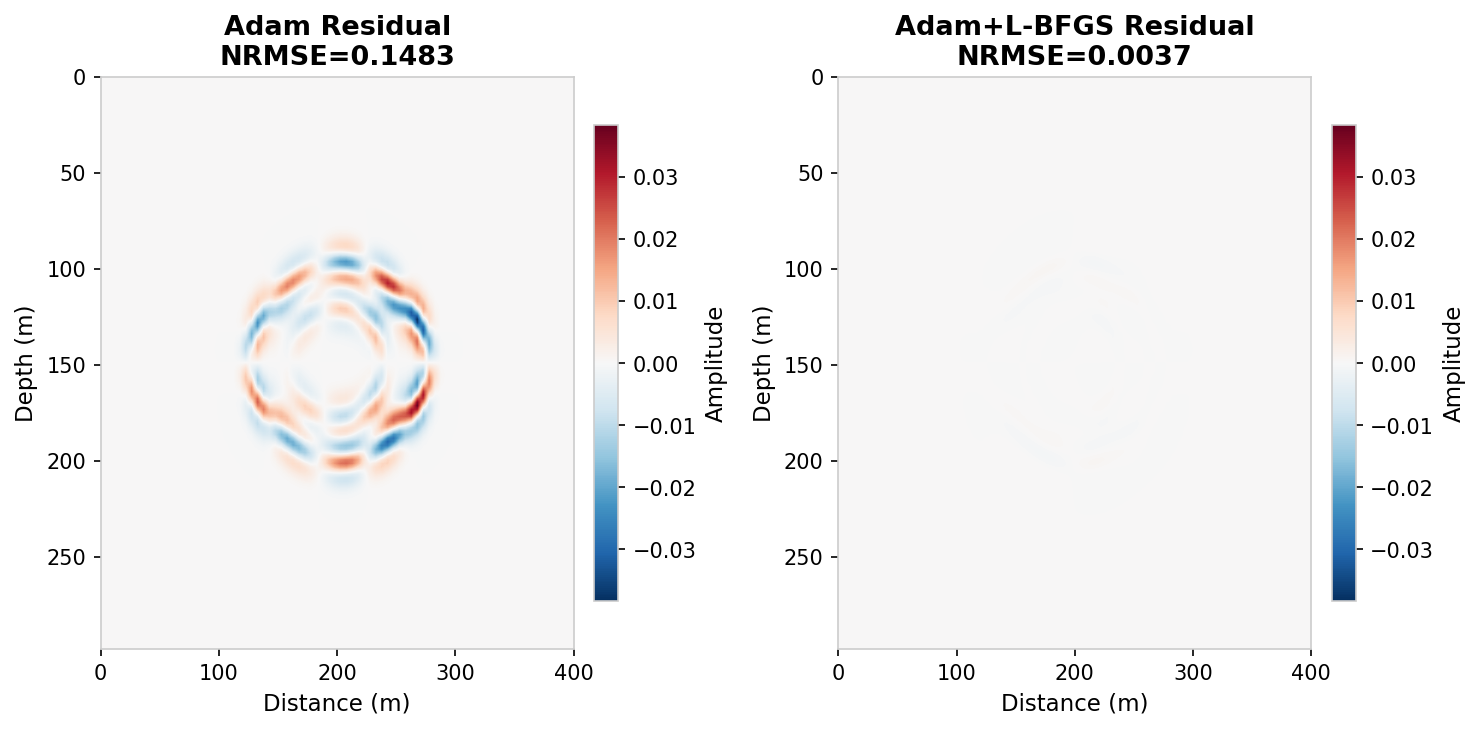

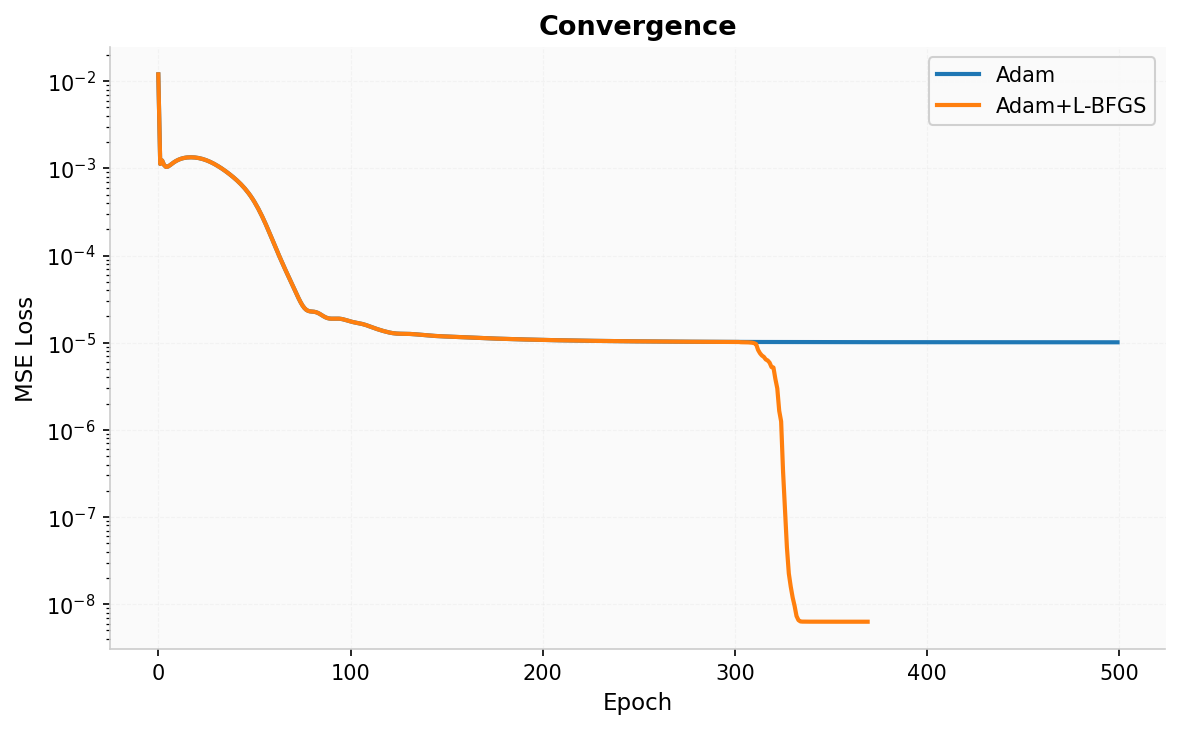

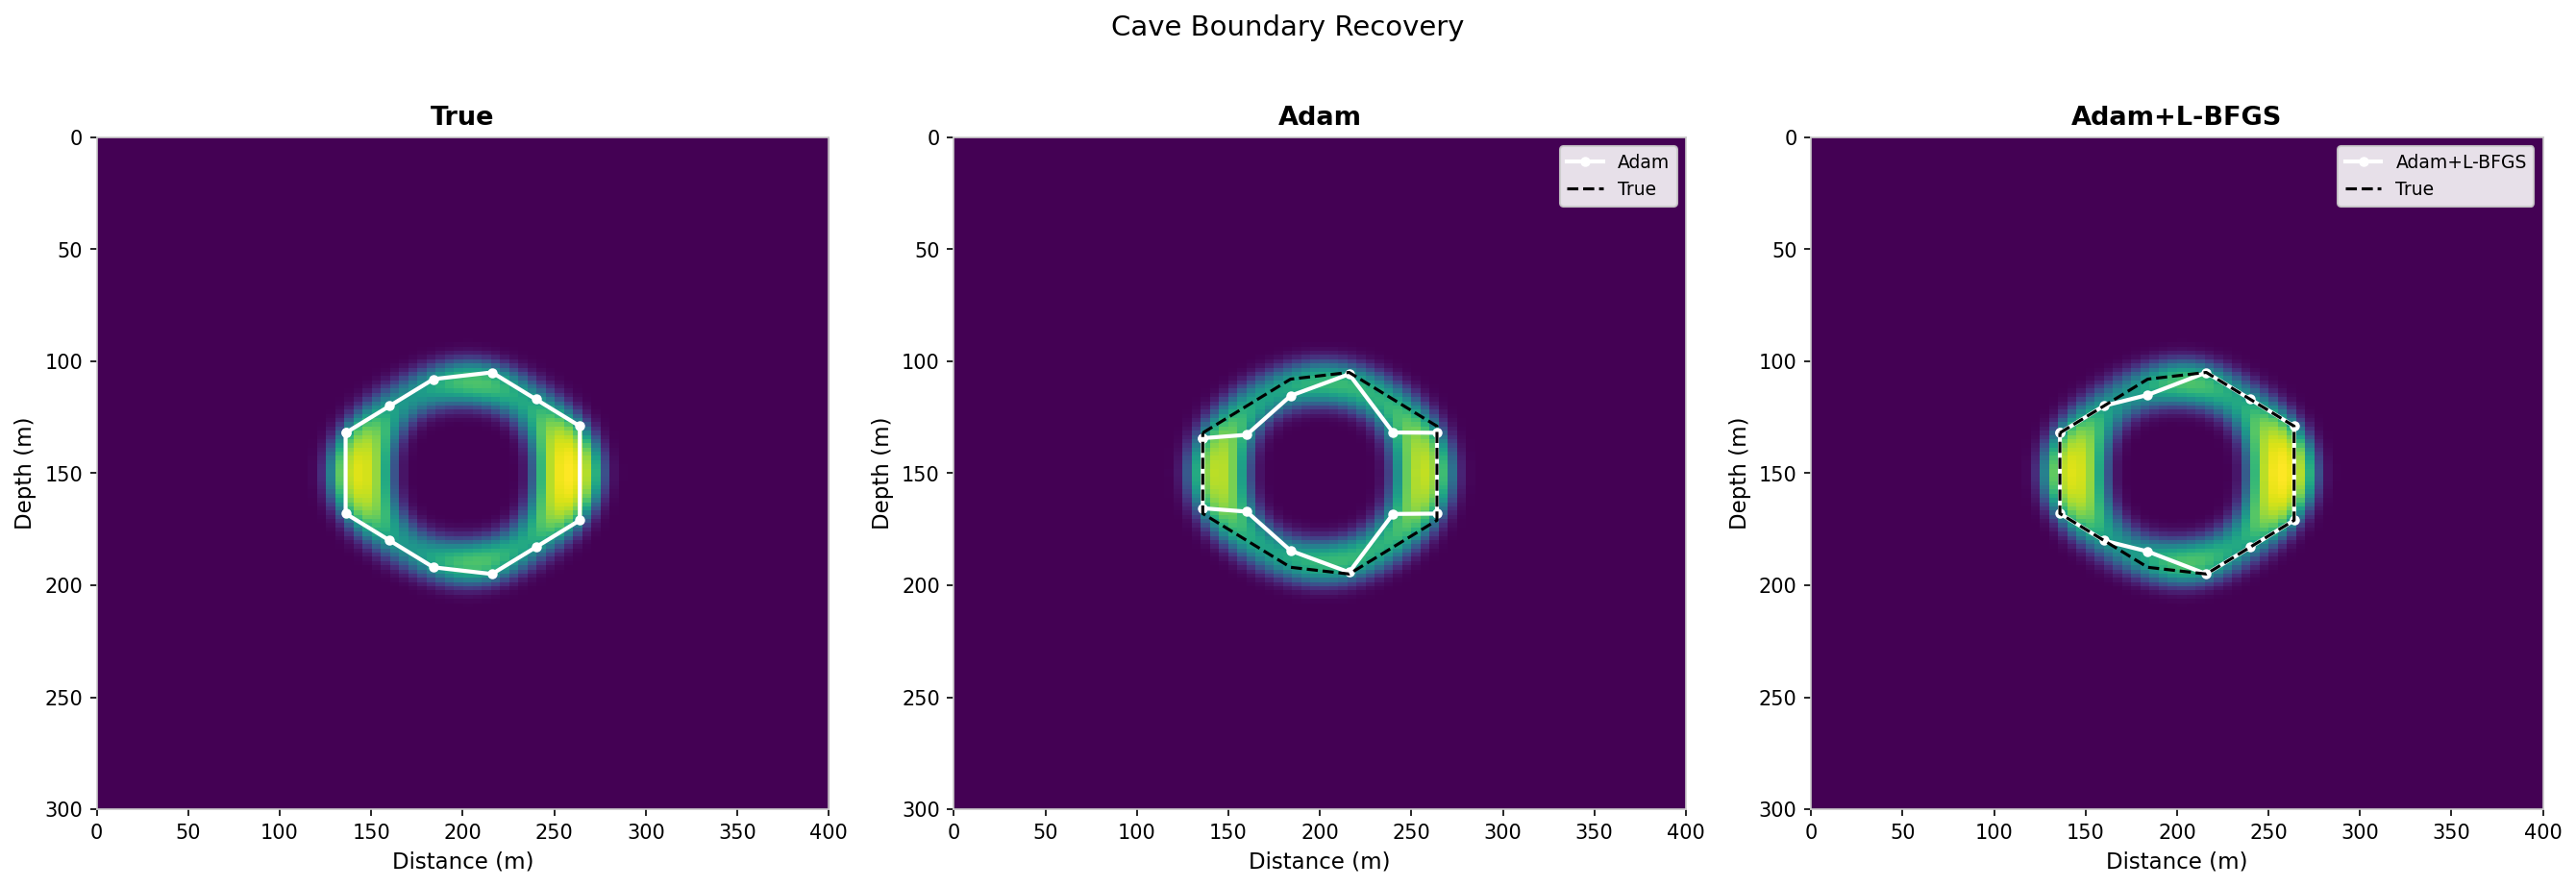

In [10]:
with torch.no_grad():
    imp_true   = build_impedance(SP_Z_TRUE)
    imp_init   = build_impedance(SP_Z_INIT)
    imp_adam    = build_impedance(sp_z_adam)
    imp_lbfgs  = build_impedance(sp_z_lbfgs)
    seis_adam   = forward_fn(sp_z_adam)
    seis_lbfgs  = forward_fn(sp_z_lbfgs)


# --- Helper: draw cave boundary from top/bottom z ---
def cave_boundary_xy(sp_z_vec):
    """Return (bx, bz) arrays tracing the cave outline in physical coords."""
    zt = sp_z_vec[:N_X].detach().cpu().numpy()
    zb = sp_z_vec[N_X:].detach().cpu().numpy()
    xp = SP_X_POS.cpu().numpy()
    # trace: left→right along top, then right→left along bottom, close
    bx = np.concatenate([xp, xp[::-1], xp[:1]]) * PHYS_X
    bz = np.concatenate([zt, zb[::-1], zt[:1]]) * PHYS_Z
    return bx, bz


# --- Row 1: Acoustic impedance ---
fig, axes = plot_comparison(
    [to_image(imp_true), to_image(imp_init),
     to_image(imp_adam), to_image(imp_lbfgs)],
    titles=['True Model', 'Initial (flat)', 'Adam', 'Adam+L-BFGS'],
    dx=DX, dz=DZ, cmap='viridis', share_clim=True,
    label='Impedance (kg/m$^2$s)',
    figsize=(20, 5),
)
plt.suptitle('Acoustic Impedance — Karst Cave Detection', fontsize=14, y=1.02)
plt.savefig(os.path.join(FIGS_DIR, '04_impedance.png'))
plt.show()

# --- Row 2: Seismic sections ---
clip = max(abs(seis_obs.min().item()), abs(seis_obs.max().item()))
fig, axes = plot_comparison(
    [to_image(seis_obs), to_image(seis_init),
     to_image(seis_adam), to_image(seis_lbfgs)],
    titles=['Observed', 'Initial', 'Adam', 'Adam+L-BFGS'],
    dx=DX, dz=DZ, cmap='seismic',
    label='Amplitude',
    figsize=(20, 5),
    vmin=-clip, vmax=clip, share_clim=False,
)
plt.suptitle('Post-stack Seismic', fontsize=14, y=1.02)
plt.savefig(os.path.join(FIGS_DIR, '04_seismic.png'))
plt.show()

# --- Row 3: Seismic residuals ---
res_adam  = seis_adam  - seis_obs
res_lbfgs = seis_lbfgs - seis_obs
nrmse_adam  = float(torch.sqrt(torch.mean(res_adam  ** 2)) / seis_obs.std())
nrmse_lbfgs = float(torch.sqrt(torch.mean(res_lbfgs ** 2)) / seis_obs.std())

fig, axes = plot_comparison(
    [to_image(res_adam), to_image(res_lbfgs)],
    titles=[f'Adam Residual\nNRMSE={nrmse_adam:.4f}',
            f'Adam+L-BFGS Residual\nNRMSE={nrmse_lbfgs:.4f}'],
    dx=DX, dz=DZ, cmap='RdBu_r', share_clim=True,
    label='Amplitude',
    figsize=(10, 5),
)
plt.savefig(os.path.join(FIGS_DIR, '04_residual.png'))
plt.show()

# --- Convergence ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(result_adam.loss_history, label='Adam', color='#1f77b4', linewidth=2)
ax.semilogy(result_lbfgs.loss_history, label='Adam+L-BFGS', color='#ff7f0e', linewidth=2)
ax.legend()
ax.set_title('Convergence')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '04_convergence.png'))
plt.show()

# --- Cave boundary recovery on impedance section ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
imp_min = to_image(imp_true).min()
imp_max = to_image(imp_true).max()

for i, (name, sp_z_inv, imp) in enumerate([
    ('True', SP_Z_TRUE, imp_true),
    ('Adam', sp_z_adam, imp_adam),
    ('Adam+L-BFGS', sp_z_lbfgs, imp_lbfgs),
]):
    ax = axes[i]
    img = to_image(imp)
    nz_img, nx_img = img.shape
    extent = [0, (nx_img - 1) * DX, (nz_img - 1) * DZ, 0]
    ax.imshow(img, aspect='auto', cmap='viridis', extent=extent,
              vmin=imp_min, vmax=imp_max)

    # Overlay inverted boundary
    bx, bz = cave_boundary_xy(sp_z_inv)
    ax.plot(bx, bz, 'w-o', ms=4, lw=2, label=name)

    # Overlay true boundary for comparison
    if name != 'True':
        tbx, tbz = cave_boundary_xy(SP_Z_TRUE)
        ax.plot(tbx, tbz, 'k--', lw=1.5, label='True')
        ax.legend(fontsize=9)

    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Depth (m)')
    ax.set_title(name)

plt.suptitle('Cave Boundary Recovery', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '04_cave_boundary.png'))
plt.show()